## 0. 실행환경 및 데이터 설정


In [18]:
# Colab 최초 1회
!pip -q install PublicDataReader finance-datareader pyarrow

import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    BASE = Path("/content/drive/MyDrive/quant")
except Exception:
    BASE = Path("./quant")
CACHE = BASE / "cache"; CACHE.mkdir(parents=True, exist_ok=True)

# --- 한국은행 ECOS ---
# https://ecos.bok.or.kr → 오픈API → 인증키 신청 (즉시 발급)
try:
    from google.colab import userdata
    ECOS_KEY = userdata.get("ECOS_KEY")
except Exception:
    ECOS_KEY = os.environ.get("ECOS_KEY", "")

ECOS_KEY = (ECOS_KEY or "").strip().strip('"').strip("'")
assert ECOS_KEY, "키가 비어 있습니다"

TENORS = {"1Y": 1.0, "3Y": 3.0, "5Y": 5.0, "10Y": 10.0, "20Y": 20.0, "30Y": 30.0}

# 통계표 817Y002 (시장금리, 일별) 항목코드
ECOS_ITEMS = {
    "1Y":  "010190000",   # 국고채 1년
    "3Y":  "010200000",   # 국고채 3년
    "5Y":  "010200001",   # 국고채 5년
    "10Y": "010210000",   # 국고채 10년
    "20Y": "010220000",   # 국고채 20년
    "30Y": "010230000",   # 국고채 30년
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. 한국은행에서 만기별 금리 가져오기


In [19]:
import requests

def ecos_series(item_code, start="20160101", end="20260910", key=ECOS_KEY):
    """ECOS 817Y002 일별 시장금리 단일 항목."""
    url = (f"https://ecos.bok.or.kr/api/StatisticSearch/{key}/json/kr/"
           f"1/10000/817Y002/D/{start}/{end}/{item_code}")
    r = requests.get(url, timeout=30); r.raise_for_status()
    js = r.json()
    if "StatisticSearch" not in js:
        raise RuntimeError(f"ECOS 응답 이상: {js}")
    rows = js["StatisticSearch"]["row"]
    df = pd.DataFrame(rows)[["TIME", "DATA_VALUE"]]
    df["TIME"] = pd.to_datetime(df["TIME"], format="%Y%m%d")
    df["DATA_VALUE"] = pd.to_numeric(df["DATA_VALUE"], errors="coerce")
    return df.set_index("TIME")["DATA_VALUE"]

def load_curve_history(force=False):
    fp = CACHE / "ktb_curve.parquet"
    if fp.exists() and not force:
        return pd.read_parquet(fp)
    out = {}
    for tn, code in ECOS_ITEMS.items():
        out[tn] = ecos_series(code)
        print(f"  {tn:>3} : {len(out[tn]):,}건")
    df = pd.DataFrame(out).sort_index().dropna(how="all")
    df = df.ffill().dropna()          # 만기별 휴장 불일치만 보정
    df.to_parquet(fp)
    return df

CURVE = load_curve_history()
print(CURVE.tail(3))

               1Y     3Y     5Y    10Y    20Y    30Y
TIME                                                
2026-09-08  3.479  3.901  4.127  4.401  4.560  4.635
2026-09-09  3.486  3.910  4.136  4.401  4.551  4.641
2026-09-10  3.507  3.930  4.186  4.453  4.548  4.661


## 2. 금리 1% 충격이 어느 정도인지 살펴보기

In [20]:
# --- §1.1 스트레스 크기의 근거 (±100bp를 왜 골랐나) ---
chg_1y = (CURVE - CURVE.shift(250)).dropna() * 100   # bp, 연간 변동

summary = pd.DataFrame({
    "표준편차(bp)": chg_1y.std().round(0),
    "|변동|>100bp 비율": (chg_1y.abs() > 100).mean().round(3),
    "5%분위": chg_1y.quantile(.05).round(0),
    "95%분위": chg_1y.quantile(.95).round(0),
})
print(summary)

     표준편차(bp)  |변동|>100bp 비율  5%분위  95%분위
1Y       85.0          0.175 -89.0  210.0
3Y       84.0          0.200 -90.0  184.0
5Y       79.0          0.188 -93.0  162.0
10Y      73.0          0.173 -98.0  146.0
20Y      71.0          0.156 -95.0  152.0
30Y      71.0          0.149 -94.0  155.0


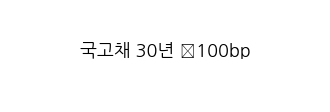

In [21]:
!apt-get install -qq fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family=fm.FontProperties(fname=font_path).get_name())
plt.rcParams['axes.unicode_minus'] = False

# 확인
plt.figure(figsize=(4, 1.2))
plt.text(.5, .5, "국고채 30년 −100bp", ha="center", fontsize=13)
plt.axis("off"); plt.show()

## 3. Nelson Siegel Curve - 금리로 매끄러운 곡선 만들기

기준일 2026-09-10
  β0(level)=4.724  β1(slope)=-1.427 β2(curv)=-1.103  λ=1.10  RMSE=2.0bp


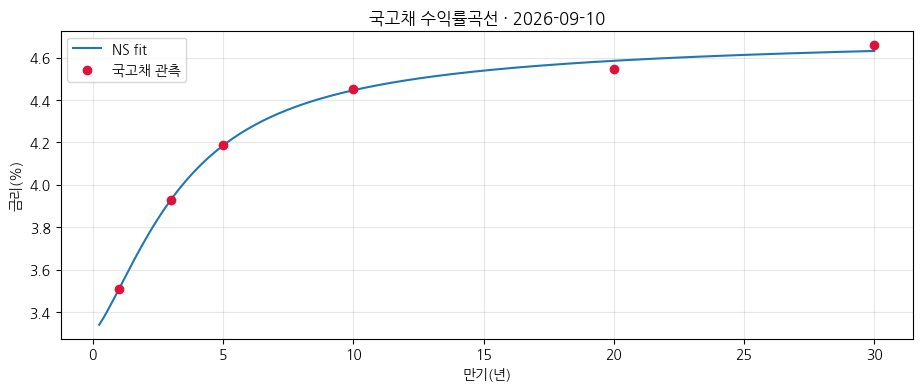

In [22]:
def ns_curve(tau, beta0, beta1, beta2, lam):
    """Nelson-Siegel. tau: 만기(년), 반환: 연 %."""
    tau = np.asarray(tau, dtype=float)
    x = tau / lam
    f1 = (1 - np.exp(-x)) / x
    f2 = f1 - np.exp(-x)
    return beta0 + beta1 * f1 + beta2 * f2

def fit_ns(tenors_yrs, yields, lam_grid=np.linspace(0.5, 5.0, 46)):
    """lambda는 격자 탐색, 나머지 3개는 그 안에서 선형 최소제곱.
    lambda까지 동시에 비선형으로 풀면 초기값에 따라 해가 튑니다."""
    t = np.asarray(tenors_yrs, float); y = np.asarray(yields, float)
    best = None
    for lam in lam_grid:
        x = t / lam
        f1 = (1 - np.exp(-x)) / x
        f2 = f1 - np.exp(-x)
        X = np.column_stack([np.ones_like(t), f1, f2])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        sse = ((X @ beta - y) ** 2).sum()
        if best is None or sse < best[0]:
            best = (sse, beta, lam)
    sse, beta, lam = best
    return dict(beta0=beta[0], beta1=beta[1], beta2=beta[2], lam=lam,
                rmse=np.sqrt(sse / len(t)))

# 기준일 커브
AS_OF = CURVE.index[-1]
obs_y = CURVE.loc[AS_OF]
obs_t = np.array([TENORS[c] for c in CURVE.columns])

NS = fit_ns(obs_t, obs_y.values)
print(f"기준일 {AS_OF:%Y-%m-%d}")
print(f"  β0(level)={NS['beta0']:.3f}  β1(slope)={NS['beta1']:.3f} "
      f"β2(curv)={NS['beta2']:.3f}  λ={NS['lam']:.2f}  RMSE={NS['rmse']*100:.1f}bp")

grid = np.linspace(0.25, 30, 200)
plt.plot(grid, ns_curve(grid, NS['beta0'], NS['beta1'], NS['beta2'], NS['lam']),
         label="NS fit")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.scatter(obs_t, obs_y.values, color="crimson", zorder=5, label="국고채 관측")
plt.xlabel("만기(년)"); plt.ylabel("금리(%)"); plt.legend()
plt.title(f"국고채 수익률곡선 · {AS_OF:%Y-%m-%d}"); plt.show()

## 4. 미래 돈을 현재 돈으로 바꾸는 할인계수 설정

In [23]:
# --- 할인함수 ---
# 가정: 국고채 YTM을 금리로 근사

def disc_factor(t, params, comp=2, kind=None, bp=0.0):
    """기준 곡선 + 만기별 충격으로 할인계수 계산."""
    t = np.asarray(t, dtype=float)

    y = ns_curve(
        t, params["beta0"], params["beta1"],
        params["beta2"], params["lam"]
    ) / 100.0

    if kind is not None:
        y += shock_bp(t, kind, bp) / 10000.0

    if np.any(1 + y / comp <= 0):
        raise ValueError("할인계수를 계산할 수 없는 금리입니다.")

    return (1 + y / comp) ** (-comp * t)

## 5. 자산과 부채가 앞으로 주고받을 돈 설정

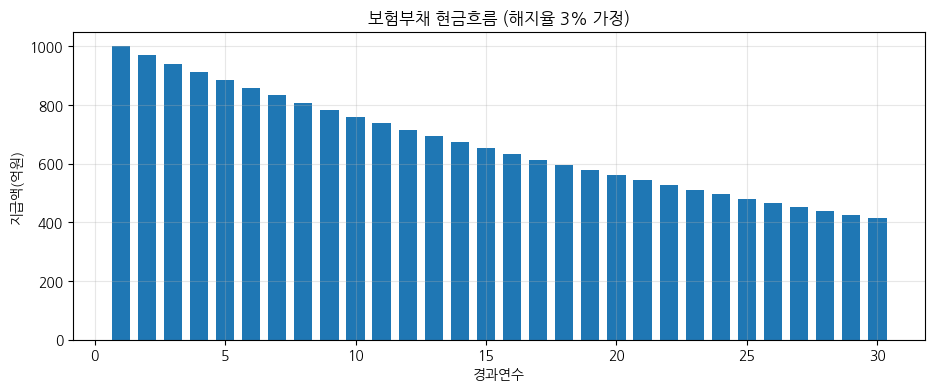

In [24]:
def bond_cashflows(maturity, coupon_rate, face=100.0, freq=2):
    """이표채 현금흐름. 반환: (시점배열[년], 금액배열)"""
    n = int(round(maturity * freq))
    t = np.arange(1, n + 1) / freq
    cf = np.full(n, face * coupon_rate / freq)
    cf[-1] += face
    return t, cf

# --- 자산: 국고채만 (신용리스크는 범위 밖) ---
# 회사채를 넣으면 손익이 금리 때문인지 스프레드 때문인지 분리가 안 됩니다.
ASSETS = [
    dict(name="국고 3년",  maturity=3,  coupon=0.030, weight=0.25),
    dict(name="국고 5년",  maturity=5,  coupon=0.032, weight=0.25),
    dict(name="국고 10년", maturity=10, coupon=0.034, weight=0.30),
    dict(name="국고 30년", maturity=30, coupon=0.035, weight=0.20),
]

# --- 부채: 저축성보험 단순화 ---
# 가정 (전부 임의, 실제 상품 아님):
#   A1. 보유계약 10만건, 평균 연 지급액 100만원
#   A2. 지급기간 30년, 매년 말 1회 지급
#   A3. 해지율 연 3% 일정 → 지급액이 매년 감소
#   A4. 사망률/신계약/옵션 미반영 → 계리 요소는 범위 밖
LIAB_YEARS   = 30
LIAB_BASE    = 1_000.0      # 억원, 1년차 지급액
LAPSE_RATE   = 0.03

def liability_cashflows():
    t = np.arange(1, LIAB_YEARS + 1, dtype=float)
    cf = LIAB_BASE * (1 - LAPSE_RATE) ** (t - 1)
    return t, cf

LT, LCF = liability_cashflows()
plt.bar(LT, LCF, width=.7)
plt.xlabel("경과연수"); plt.ylabel("지급액(억원)")
plt.title("보험부채 현금흐름 (해지율 3% 가정)"); plt.show()

## 6. 현재가치와 금리 민감도 계산

In [25]:
def pv_stats(t, cf, params, comp=2):
    """현재가치와 평행 금리 충격에 대한 민감도."""
    t = np.asarray(t, dtype=float)
    cf = np.asarray(cf, dtype=float)

    pv_i = cf * disc_factor(t, params, comp)
    pv = pv_i.sum()

    if pv <= 0:
        raise ValueError("현재가치가 양수인 현금흐름을 입력하세요.")

    macd = (t * pv_i).sum() / pv

    # 1bp = 금리 소수 단위 0.0001
    h = 0.0001

    pv_up = (cf * disc_factor(t, params, comp, kind="parallel", bp=1.0)).sum()
    pv_dn = (cf * disc_factor(t, params, comp, kind="parallel", bp=-1.0)).sum()
    dv01 = (pv_dn - pv_up) / 2.0
    duration = (pv_dn - pv_up) / (2.0 * pv * h)
    convexity = (pv_up + pv_dn - 2.0 * pv) / (pv * h**2)

    return {
        "PV": pv,
        "MacD": macd,
        # 기존 후속 코드와 호환되도록 키 이름 유지.
        # 의미는 평행 곡선 이동에 대한 유효듀레이션이다.
        "ModD": duration,
        "Convexity": convexity,
        "DV01": dv01,
    }

## 7. 만기별 금리 충격 시나리오 설정

In [26]:
def shock_bp(t, kind, bp, pivot=10.0, lo=1.0, hi=30.0):
    """
    parallel: 모든 만기 +bp
    steepening: lo에서 -bp, pivot에서 0, hi에서 +bp
    flattening: steepening의 반대

    구간별 로그만기 선형 보간.
    lo 미만과 hi 초과에서는 끝점 충격을 유지한다.
    """
    t = np.asarray(t, dtype=float)

    if kind == "parallel":
        return np.full_like(t, float(bp))
    if not (0 < lo < pivot < hi):
        raise ValueError("0 < lo < pivot < hi 조건이 필요합니다.")

    tc = np.clip(t, lo, hi)
    u = np.where(
        tc <= pivot,
        np.log(tc / pivot) / np.log(pivot / lo),
        np.log(tc / pivot) / np.log(hi / pivot),
    )

    if kind == "steepening":
        return bp * u
    if kind == "flattening":
        return -bp * u
    raise ValueError(f"알 수 없는 시나리오: {kind}")

# 실제 충격 크기 확인
check_t = np.array([0.5, 1, 3, 5, 10, 20, 30])
print(pd.DataFrame({
    "만기(년)": check_t,
    "Steepening 충격(bp)": shock_bp(
        check_t, "steepening", 50 ),
    "Flattening 충격(bp)": shock_bp(
        check_t, "flattening", 50 ),
}).round(2))

   만기(년)  Steepening 충격(bp)  Flattening 충격(bp)
0    0.5             -50.00              50.00
1    1.0             -50.00              50.00
2    3.0             -26.14              26.14
3    5.0             -15.05              15.05
4   10.0               0.00              -0.00
5   20.0              31.55             -31.55
6   30.0              50.00             -50.00


## 8. 자산·부채 현재가치 및 금리 민감도 산출

In [27]:
rows = []
for a in ASSETS:
    t, cf = bond_cashflows(a['maturity'], a['coupon'])
    s = pv_stats(t, cf, NS)
    rows.append({"항목": a['name'], "비중": a['weight'], **s})

# 자산 합산 — 비중대로 액면 스케일링
TOTAL_ASSET_PV = 12_000.0        # 억원, 부채 PV와 비슷하게 맞춰둠
A_T, A_CF = [], []
for a in ASSETS:
    t, cf = bond_cashflows(a['maturity'], a['coupon'])
    unit_pv = (cf * disc_factor(t, NS)).sum()
    scale = TOTAL_ASSET_PV * a['weight'] / unit_pv
    A_T.append(t); A_CF.append(cf * scale)
A_T = np.concatenate(A_T); A_CF = np.concatenate(A_CF)

A = pv_stats(A_T, A_CF, NS)
L = pv_stats(LT, LCF, NS)

print(pd.DataFrame([
    {"구분": "자산", **A},
    {"구분": "부채", **L},
    {"구분": "순자산", "PV": A['PV'] - L['PV'], "MacD": np.nan,
     "ModD": np.nan, "Convexity": np.nan, "DV01": A['DV01'] - L['DV01']},
]).round(2))

    구분        PV   MacD  ModD  Convexity   DV01
0   자산  12000.00   7.91  7.74     114.60   9.29
1   부채  11874.99  10.20  9.97     160.12  11.85
2  순자산    125.01    NaN   NaN        NaN  -2.55


## 9. 자산·부채 듀레이션 갭과 순 DV01 분석

In [28]:
# 금액을 반영한 듀레이션 갭
gap = (
    A["ModD"]
    - (L["PV"] / A["PV"]) * L["ModD"]
)
print(f"금액을 반영한 듀레이션 갭: {gap:+.3f}년")
print(f"순 DV01: {A['DV01'] - L['DV01']:+.3f} 억원/bp")

금액을 반영한 듀레이션 갭: -2.129년
순 DV01: -2.555 억원/bp


## 10. Stress test - 현재 포트폴리오

In [29]:
SCENARIOS = [
    ("기준", None, 0),
    ("평행 +100bp", "parallel", 100),
    ("평행 −100bp", "parallel", -100),
    ("Steepening: 1Y −50 / 30Y +50bp", "steepening", 50),
    ("Flattening: 1Y +50 / 30Y −50bp", "flattening", 50),
]

def run_stress(a_t, a_cf, l_t, l_cf, base=None):
    if base is None:
        base = NS
    base_apv = (a_cf * disc_factor(a_t, base)).sum()
    base_lpv = (l_cf * disc_factor(l_t, base)).sum()
    base_ne = base_apv - base_lpv
    out = []

    for name, kind, bp in SCENARIOS:
        apv = (a_cf * disc_factor(a_t, base, kind=kind, bp=bp)).sum()
        lpv = (l_cf * disc_factor(l_t, base, kind=kind, bp=bp)).sum()

        out.append({
            "시나리오": name,
            "자산PV": apv,
            "부채PV": lpv,
            "자산변화": apv - base_apv,
            "부채변화": lpv - base_lpv,
            "순자산": apv - lpv,
            "순자산변화": apv - lpv - base_ne,
        })
    return pd.DataFrame(out)
print("── 현재 포트폴리오 ──")
print(run_stress(A_T, A_CF, LT, LCF).round(1))

── 현재 포트폴리오 ──
                             시나리오     자산PV     부채PV    자산변화    부채변화    순자산  순자산변화
0                              기준  12000.0  11875.0     0.0     0.0  125.0    0.0
1                       평행 +100bp  11135.0  10779.5  -865.0 -1095.5  355.5  230.5
2                       평행 −100bp  13003.2  13161.3  1003.2  1286.3 -158.1 -283.1
3  Steepening: 1Y −50 / 30Y +50bp  11909.5  11680.4   -90.5  -194.6  229.1  104.1
4  Flattening: 1Y +50 / 30Y −50bp  12111.2  12090.3   111.2   215.3   20.9 -104.1


## 11. stress test - 듀레이션 영향

In [30]:
# --- §7.1 갭을 0으로 맞춘 뒤 다시 때립니다 ---
# 이게 이 프로젝트의 논지입니다.
def build_assets(w30, total_pv=TOTAL_ASSET_PV):
    """30년물 비중 w30, 나머지는 3/5/10년에 원래 비율대로 배분."""
    rest = np.array([.25, .25, .30]); rest = rest / rest.sum() * (1 - w30)
    ws = list(rest) + [w30]
    T, C = [], []
    for a, w in zip(ASSETS, ws):
        t, cf = bond_cashflows(a['maturity'], a['coupon'])
        unit = (cf * disc_factor(t, NS)).sum()
        T.append(t); C.append(cf * total_pv * w / unit)
    return np.concatenate(T), np.concatenate(C)

def gap_at(w30):
    """자산과 부채의 순 DV01. 단위: 억원/bp."""
    t, cf = build_assets(w30)
    return pv_stats(t, cf, NS)["DV01"] - L["DV01"]
from scipy.optimize import brentq
g0 = gap_at(0.0)
g1 = gap_at(1.0)
if np.isclose(g0, 0.0):
    W_MATCH = 0.0
elif np.isclose(g1, 0.0):
    W_MATCH = 1.0
elif g0 * g1 < 0:
    W_MATCH = brentq(gap_at, 0.0, 1.0)
else:
    raise ValueError(
        "현재 비중 조정 방식에서는 순 DV01을 0으로 맞출 수 없습니다. "
        f"30년물 0%: {g0:+.3f}, 100%: {g1:+.3f} 억원/bp"
    )

M_T, M_CF = build_assets(W_MATCH)
M = pv_stats(M_T, M_CF, NS)
print(f"DV01 매칭 30년물 비중: {W_MATCH:.2%}")
print(f"매칭 후 순 DV01: {M['DV01'] - L['DV01']:+.6f} 억원/bp")
print(run_stress(M_T, M_CF, LT, LCF).round(1))

DV01 매칭 30년물 비중: 38.31%
매칭 후 순 DV01: +0.000000 억원/bp
                             시나리오     자산PV     부채PV    자산변화    부채변화    순자산  순자산변화
0                              기준  12000.0  11875.0     0.0     0.0  125.0    0.0
1                       평행 +100bp  10916.5  10779.5 -1083.5 -1095.5  137.0   11.9
2                       평행 −100bp  13303.6  13161.3  1303.6  1286.3  142.3   17.3
3  Steepening: 1Y −50 / 30Y +50bp  11769.0  11680.4  -231.0  -194.6   88.6  -36.4
4  Flattening: 1Y +50 / 30Y −50bp  12270.2  12090.3   270.2   215.3  179.9   54.9


## 12. DV01 매칭 전후 스트레스 결과 비교

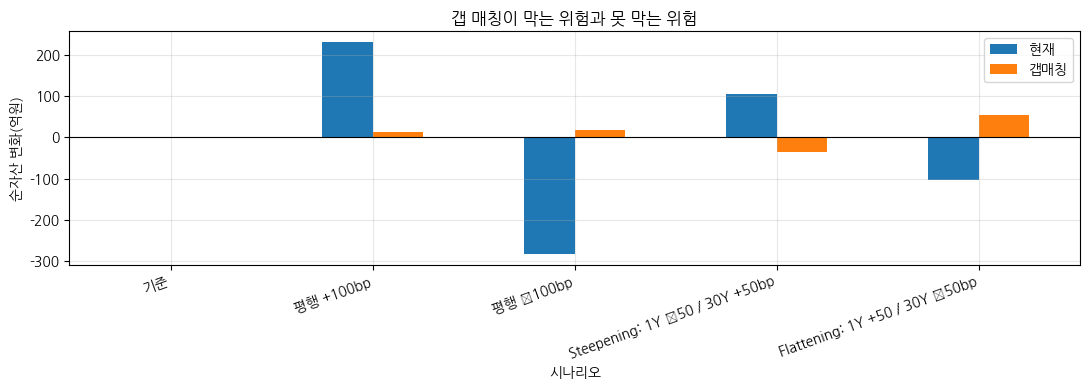

In [31]:
# 갭 매칭 전후를 나란히
cmp_df = pd.DataFrame({
    "시나리오": [s[0] for s in SCENARIOS],
    "현재": run_stress(A_T, A_CF, LT, LCF)["순자산변화"],
    "갭매칭": run_stress(M_T, M_CF, LT, LCF)["순자산변화"],
})
ax = cmp_df.set_index("시나리오").plot.bar(figsize=(11, 4))
ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("순자산 변화(억원)")
ax.set_title("갭 매칭이 막는 위험과 못 막는 위험")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## 13. 손익 분해 — 듀레이션이 설명하는 것과 컨벡시티가 설명하는 것

In [32]:
decomp = []
for label, t, cf in [("현재", A_T, A_CF), ("DV01 매칭", M_T, M_CF)]:
    asset = pv_stats(t, cf, NS)
    stress = run_stress(t, cf, LT, LCF).set_index("시나리오")
    net_dv01 = asset["DV01"] - L["DV01"]
    net_dollar_convexity = asset["PV"] * asset["Convexity"] - L["PV"] * L["Convexity"]

    for bp, scenario in [(100, "평행 +100bp"), (-100, "평행 −100bp")]:
        dy = bp / 10000.0
        first = -net_dv01 * bp
        second = 0.5 * net_dollar_convexity * dy**2
        actual = stress.loc[scenario, "순자산변화"]
        decomp.append({
            "구성": label, "충격(bp)": bp, "1차 효과": first, "2차 효과": second,
            "1차+2차": first + second, "실제 재평가": actual, "잔차": actual - first - second
        })

print("단위: 억원")
print(pd.DataFrame(decomp).round(2))

단위: 억원
        구성  충격(bp)   1차 효과  2차 효과   1차+2차  실제 재평가    잔차
0       현재     100  255.49 -26.31  229.17  230.46  1.28
1       현재    -100 -255.49 -26.31 -281.80 -283.13 -1.34
2  DV01 매칭     100   -0.00  14.33   14.33   11.94 -2.39
3  DV01 매칭    -100    0.00  14.33   14.33   17.25  2.92


## 14. 채권 비중별 IRR 및 최악손실 최소화 분석

최악손실 최소 비중: 36.08%  (손실 19.3억, 순DV01 -0.311억/bp)
DV01 매칭 비중: 38.31%  (손실 36.4억, 순DV01 +0.000억/bp)


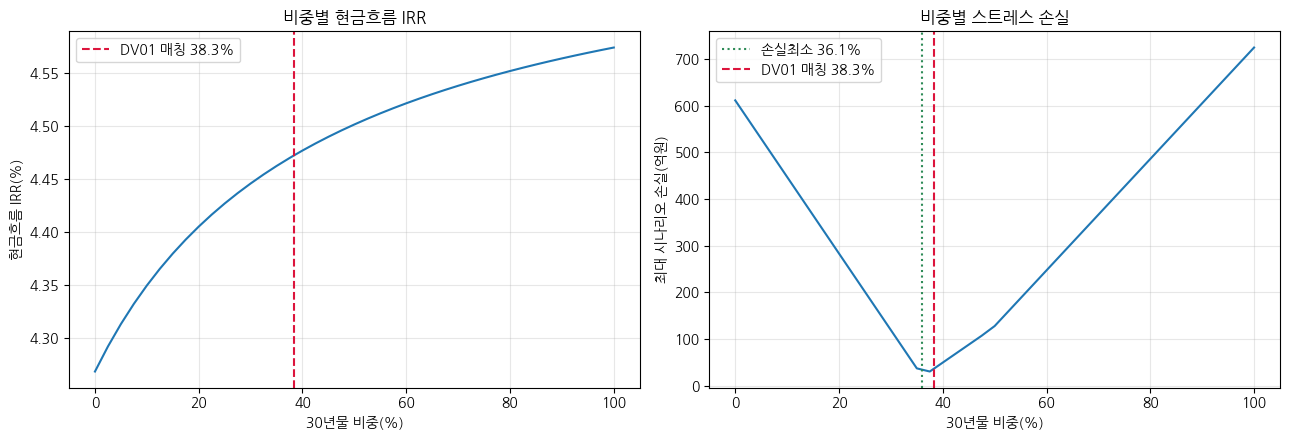

30년물 비중: 20.0% → 38.3%
현금흐름 IRR 변화: +6.7bp
최대 시나리오 손실: 283.1 → 36.4억원


In [33]:
def port_yield(w30):
    """전체 현금흐름의 반기복리 연율 IRR(%)."""
    t, cf = build_assets(w30)
    pv = (cf * disc_factor(t, NS)).sum()
    def objective(y):
        return (cf / (1 + y / 2.0)**(2.0 * t)).sum() - pv
    return brentq(objective, -0.10, 1.0) * 100.0

def worst_loss(w30):
    """설정한 시나리오 중 최대 손실액. 손실을 양수로 표시."""
    t, cf = build_assets(w30)
    changes = run_stress(t, cf, LT, LCF)["순자산변화"]
    return max(0.0, -changes.min())

W = np.unique(np.r_[np.linspace(0.0, 1.0, 41), W_MATCH])
front = pd.DataFrame({
    "w30": W,
    "net_dv01": [gap_at(w) for w in W],
    "irr": [port_yield(w) for w in W],
    "worst_loss": [worst_loss(w) for w in W]
})
from scipy.optimize import minimize_scalar
opt = minimize_scalar(worst_loss, bounds=(0, 1), method="bounded")
if not opt.success:
    raise RuntimeError(opt.message)

# bounded 방식은 끝점을 직접 평가하지 않으므로 0%, 100%도 비교
w_opt = min([0.0, float(opt.x), 1.0], key=worst_loss)
print(f"최악손실 최소 비중: {w_opt:.2%}  (손실 {worst_loss(w_opt):.1f}억, 순DV01 {gap_at(w_opt):+.3f}억/bp)")
print(f"DV01 매칭 비중: {W_MATCH:.2%}  (손실 {worst_loss(W_MATCH):.1f}억, 순DV01 {gap_at(W_MATCH):+.3f}억/bp)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(front.w30 * 100, front.irr)
axes[0].set(xlabel="30년물 비중(%)", ylabel="현금흐름 IRR(%)", title="비중별 현금흐름 IRR")
axes[1].plot(front.w30 * 100, front.worst_loss)
axes[1].set(xlabel="30년물 비중(%)", ylabel="최대 시나리오 손실(억원)", title="비중별 스트레스 손실")
axes[1].axvline(w_opt * 100, color="seagreen", ls=":", label=f"손실최소 {w_opt:.1%}")
for ax in axes:
    ax.axvline(W_MATCH * 100, color="crimson", linestyle="--", label=f"DV01 매칭 {W_MATCH:.1%}")
    ax.legend()
plt.tight_layout()
plt.show()

current_w = ASSETS[-1]["weight"]
irr_change_bp = (port_yield(W_MATCH) - port_yield(current_w)) * 100.0
print(f"30년물 비중: {current_w:.1%} → {W_MATCH:.1%}")
print(f"현금흐름 IRR 변화: {irr_change_bp:+.1f}bp")
print(f"최대 시나리오 손실: {worst_loss(current_w):.1f} → {worst_loss(W_MATCH):.1f}억원")

## 부록. ECOS 국고채 항목코드 확인

In [34]:
url = f"https://ecos.bok.or.kr/api/StatisticItemList/{ECOS_KEY}/json/kr/1/200/817Y002"
items = pd.DataFrame(requests.get(url).json()["StatisticItemList"]["row"])
print(items[items.ITEM_NAME.str.contains("국고", na=False)][["ITEM_CODE","ITEM_NAME"]])

    ITEM_CODE ITEM_NAME
2   010200001   국고채(5년)
7   010190000   국고채(1년)
8   010210000  국고채(10년)
9   010220000  국고채(20년)
10  010230000  국고채(30년)
11  010195000   국고채(2년)
12  010200000   국고채(3년)
25  010240000  국고채(50년)
